# Segmentação de Imagens com CLIPSeg (Nova Versão)

Este notebook utiliza o modelo **CIDAS/clipseg-rd64-refined** (CLIPSegForImageSegmentation) para realizar a segmentação de fotos específicas com prompts personalizados para cada uma.

In [8]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
from transformers import logging

logging.set_verbosity_error()

model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

print(f"Modelo {model_name} carregado com sucesso!")


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

Modelo CIDAS/clipseg-rd64-refined carregado com sucesso!


In [9]:
image_dir = "../assets/"

images_and_prompts = {
    "passaro.jpg": ["bird", "branch", "eye"],
    "caoegato.jpg": ["cat", "dog", "floor"],
    "pizza.jpg": ["pizza slice", "tomato", "cheese"]
}

def segment_image(image_path, prompts):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.sigmoid(outputs.logits)

    if len(prompts) == 1:
        preds = preds.unsqueeze(0)

    n_prompts = len(prompts)
    fig, ax = plt.subplots(1, n_prompts + 1, figsize=((n_prompts + 1) * 4, 4))

    ax[0].imshow(image)
    ax[0].set_title(f"Original: {os.path.basename(image_path)}")
    ax[0].axis("off")

    for i in range(n_prompts):
        ax[i+1].imshow(preds[i])
        ax[i+1].set_title(f"Prompt: {prompts[i]}")
        ax[i+1].axis("off")

    plt.tight_layout()
    plt.show()


Analisando passaro.jpg...


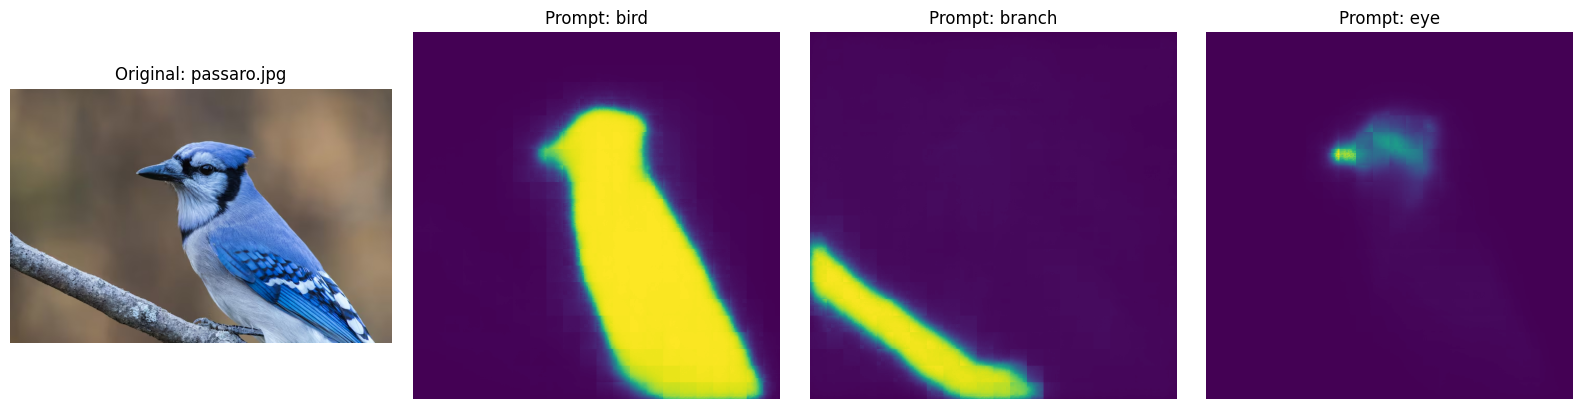

Analisando caoegato.jpg...


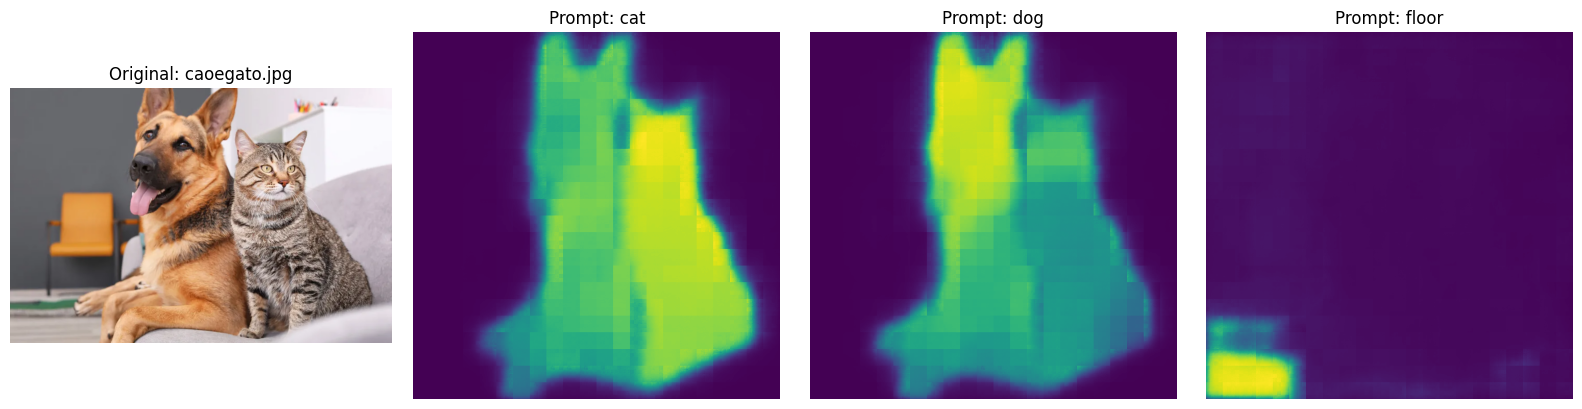

Analisando pizza.jpg...


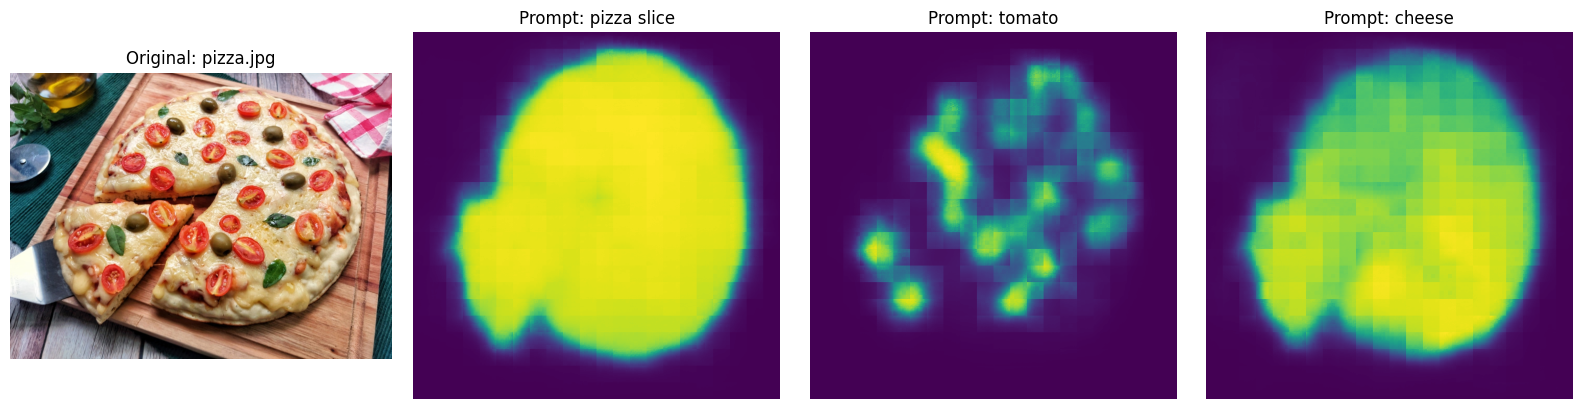

In [10]:

for img_name, prompts in images_and_prompts.items():
    full_path = os.path.join(image_dir, img_name)
    if os.path.exists(full_path):
        print(f"Analisando {img_name}...")
        segment_image(full_path, prompts)
    else:
        print(f"Arquivo {img_name} não encontrado em {image_dir}.")
